# Мататематички методи за машинско учење 2025/2026
## Домаћи задатак број 5

<div class="alert alert-block alert-danger">
<b>Име и презиме студента:</b> Danilo Milošević

<b>Број индекса:</b> 1732
    
</div>    

<div class="alert alert-block alert-info">
<b>Упутство за израду и предају домаћег задатака: </b> 
    
    1. Пре почетка израде промените име датотеке у 05Domaci_Ime_Prezime. (убаците своје име и презиме) 
    2. Попуните ћелију испод наслова одговарајућим подацима. 
    1. Употреба ћирилице није обавезна за предају домаћег задатка.
    4. За решавање задатака, уколико је потребно, отворите испод текста задатка додатне ћелије за уписивање текстуалног одговора (Markdown) или програмског кода (Code).
    1. Сва израчунавања, уколико је потребно, вршити у Python-у.
    5. Након завршетка израде решења домаћег Notebook документ сачувати у pdf формату и проследити га наставнику. То можете да урадите или кроз Teams или на мејл адресу jovana.dzunic@elfak.ni.ac.rs

</div> 

In [2]:
import numpy as np
import numpy.random as rndm
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz

**Задатак 1.** У многим AI алгоритмима користимо kernel матрицу или Грамову матрицу да бисмо мерили сличност између података. Да би алгоритам радио коректно, ова матрица мора бити позитивно дефинитна.

**a)**
Нека је дат скуп вектора (података)  
$$
x_1, x_2, \dots, x_n \in \mathbb{R}^d,
$$
смештених дуж врста матрице $X.$
Дефинишимо Грамову матрицу  
$$
G \in \mathbb{R}^{n \times n}
$$
тако да је  
$$
G_{ij} = x_i^T x_j.
$$

Доказати да је Грамова матрица  
$$
G = X X^T
$$
увек позитивно семидефинитна.

(5 поена)

Prvo dokažimo da je $G$ simetrična. Koristimo činjenicu da je skalarni proizvod komutativna operacija.
\begin{align*}
G_{ij} &= x_i^Tx_j = x_i \cdot x_j = x_j \cdot x_i\\
&= x_j^Tx_i = G_{ji}\\
&\Rightarrow G = G^T
\end{align*}

Sada je potrebno još dokazati da
\begin{align*}
x^TGx &\geq 0 \\
\\
x^TGx &= x^T(XX^T)x = (X^Tx)^T(X^Tx) = \|X^Tx\|^2 \geq 0
\end{align*}
Dakle, $G$ je pozitivno semidefintna matrica.


**б)** Ако Грамовој матрици $G$ додамо члан $\lambda I$ (где је $\lambda > 0$), доказати да резултат постаје строго позитивно дефинитна матрица.  
Ово се у AI литератури назива **регуларизација Тихонова** или **Ridge**.

(5 поена)

\begin{align*}
x^T (G+\lambda I)x &\gt 0, \forall x \neq 0, \lambda \gt 0 \\
\\
x^T (G+\lambda I)x &= (x^TG + \lambda x^T I)x = x^TGx + \lambda I x^T x\\
&= \|X^Tx\|^2 + \lambda x^Tx = \|X^Tx\|^2 + \lambda \|x\|^2\\
\\
\|X^Tx\|^2 &\geq 0\\
\lambda \|x\|^2 &\gt 0\\
&\Rightarrow x^T (G+\lambda I)x \gt 0\\
\end{align*}

***

**Задатак 2.** **Инверзни проблеми**

Инверзни проблеми (или повратни проблеми) су математички проблеми у којима, уместо да израчунамо резултат на основу улазних података (као код директних проблема), ми тражимо узрок, унутрашње карактеристике или параметре система на основу познатих мерења, података или ефеката на излазу.

То је процес враћања уназад - од онога што видимо (резултат) до онога што је то узроковало (параметре).

**Директан проблем:**  Знамо модел $K$ и улаз $x$, израчунавамо излаз  $y = Kx.$

Другим речима, знамо узрок (нпр. облик објекта, материјал) и модел како се он понаша.  
Израчунавамо резултат (нпр. како објекат изгледа на слици, како се шири топлота).

**Инверзни проблем:**  Знамо излаз $y$ и модел $K$, тражимо улаз $x = K^{-1}y.$


Знамо резултат (нпр. слику) и модел.  
Циљ је да пронађемо узрок (нпр. прави облик објекта, непознате карактеристике материјала).

**Особине инверзних проблема**

За разлику од директних проблема који су обично добро постављени (постоји јединствено решење), инверзни проблеми често **немају јединствено решење**, или су решења **веома осетљива на грешке у подацима** (лоше условљени).

Жак Адамар је дефинисао да је инверзни проблем **коректно постављен (well-posed)** ако су испуњени следећи услови:

1. **Решење постоји.**  
2. **Решење је јединствено.**  
3. **Решење је стабилно** или добро условљено (непрекидно зависи од података $y$).

Ако било који од ових услова није испуњен (што је најчешћи случај у вештачкој интелигенцији и обради сигнала), кажемо да је проблем **некоректно постављен (ill‑posed)** према Адамару.

**а)** Нека је $K \in M_{n \times n}$ симетрична, позитивно дефинитна матрица са сопственим вредностима  
$$
\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_n > 0
$$
и одговарајућим ортонормираним сопственим векторима  
$$ q_1, \dots, q_n.$$
Спектрална декомпозиција матрице гласи:
$$
K = Q \Lambda Q^T,
$$
где је $\Lambda = \mathrm{diag}(\lambda_1, \dots, \lambda_n)$.

Показати да се решење $x$ инверзног проблема може записати у облику
$$
x = \sum_{i=1}^{n} \frac{1}{\lambda_i} (q_i^T y)\, q_i.
$$
Коју врсту трансформације вектора $y$ представља израз $(q_i^T y)\, q_i?$ 

(5 поена)

S obzirom da je $K$ spektralna dekompozicija, postoji inverzna matrica $K^{-1} = Q\Lambda^{-1}Q^T$
\begin{align*}
x &= K^{-1}y = Q\Lambda^{-1}Q^T y\\
\\
Q^T y &= \begin{bmatrix} q_1^T y \\ q_2^T y \\ \vdots \\ q_n^T y \end{bmatrix}\\
\Lambda^{-1}(Q^T y) &= \begin{bmatrix} \frac{1}{\lambda_1} q_1^T y \\ \frac{1}{\lambda_2} q_2^T y \\ \vdots \\ \frac{1}{\lambda_n} q_n^T y \end{bmatrix}\\
Q(\Lambda^{-1}Q^T y) &= \sum_{i=1}^n \frac{1}{\lambda_i}(q_i^T y)\,q_i\\
\end{align*}

Izraz $(q_i^T y)q_i$ predstavlja ortogonalnu projekciju vektora $y$ na pravac $q_i$.

**б)** Када уместо $y$ посматрамо зашумљене податке
$$
y_\varepsilon = y + \varepsilon,
$$
решење инверзног проблема постаје
$$
x_\varepsilon = K^{-1} y_\varepsilon = K^{-1}(y + \varepsilon)
= x + K^{-1}\varepsilon.
$$
Записати $K^{-1}\varepsilon$ по угледу на формулу из дела под а).
Нека је сопствена вредност $\lambda_n\approx0$ блиска нули. Шта се дешава са решењем када се подацима $y$ дода чак и минималан шум $\varepsilon$ у оваквим околностима? Сопствене вредности $\frac{1}{\lambda_i}$ инверзне матрице $K^{-1}$ посматрати као појачавач шума. Објаснити зашто ово крши Адамаров трећи услов о стабилности.

(5 поена)

\begin{align*}
K^{-1}\varepsilon &= \sum_{i=1}^n \frac{1}{\lambda_i}(q_i^T \varepsilon)q_i\\
x_\varepsilon &= x + \sum_{i=1}^n \frac{1}{\lambda_i}(q_i^T \varepsilon)q_i\\
\end{align*}

Član koji odgovara sopstvenoj vrednosti $\lambda_n$ је $\frac{1}{\lambda_n}(q_n^T \varepsilon)\,q_n$. Čak i ako je šum $\varepsilon$ veoma mali $\frac{1}{\lambda_n}$ može biti ogroman, pa ta komponenta dominira i maskira pravu vrednost $x$.

Adamarov treći uslov zahteva neprekidnu zavisnost od podataka, tj da mala promena u $y$ izaziva malu promenu u $x$. U ovom slučaju to ne važi, jer koliko god smanjili šum, prisutnost $\lambda_n$ koja je približno jednaka 0 deluje kao neograničen pojačavač šuma. Time čak i mala promena vrednosti $y$ dodavanjem šuma izaziva ogromne promene vrednosti $x$.

**в)** Да бисмо решили проблем нестабилности и обезбедили трећи Адамаров услов, користимо
**Тихоновљеву регуларизацију** у односу на величину проблема:
$$
(K + n\lambda I)x = y, \qquad \lambda > 0.
$$
Тада важи:
$$
K + n\lambda I = Q(\Lambda + n\lambda I)Q^T,
$$
$$
(K + n\lambda I)^{-1}
= Q(\Lambda + n\lambda I)^{-1}Q^T.
$$
Регуларизовано решење може да се запише у облику:
$$
x_\lambda
= \sum_{i=1}^{n} 
\frac{1}{\lambda_i + n\lambda}\,(q_i^T y)\, q_i.
$$
Описати на који начин фактор регуларизације утиче на фактор појачања шума.

(5 поена)

U tom slučaju važi

\begin{align*}
K^{-1}\varepsilon &= \sum_{i=1}^n \frac{1}{\lambda_i + n \lambda}(q_i^T \varepsilon)q_i\\
x_\varepsilon &= x + \sum_{i=1}^n \frac{1}{\lambda_i + n \lambda}(q_i^T \varepsilon)q_i\\
\end{align*}

Član koji odgovara sopstvenoj vrednosti $\lambda_n$ је $\frac{1}{\lambda_n + n \lambda}(q_n^T \varepsilon)\,q_n$. Dodavanjem male vrednosti $n\lambda$ izbegavamo deljene sa $\lambda_n$ koji je vrlo mali broj (teži nuli), pa time izbegavamo i neograničeno pojačavanje šuma.

**г)** У овом делу ћемо практично видети како регуларизација спречава "експлозију" шума која је карактеристична за некоректне проблеме. нПокренути код у наставку за креирање елемената инверзног проблема.

In [3]:
# 1. Формирање лоше условљене матрице K (димензије 50x50)
n = 50
A = np.random.randn(n, n)
U, S, Vt = np.linalg.svd(A)

# Вештачки постављамо сопствене вредности тако да експоненцијално опадају ка нули
# Ово моделује типичан инверзни проблем који је некоректно постављен
S = np.exp(-0.5 * np.arange(n)) 
K = U @ np.diag(S) @ U.T 

# 2. Правимо стварно решење 'x_true' и мерења 'y' са додатком малог шума
x_true = np.random.randn(n)
noise_level = 0.001
y_noisy = K @ x_true + noise_level * np.random.randn(n)

ВАШ ЗАДАТАК:
1. Израчунати наивно решење `x_naive = np.linalg.inv(K) @ y_noisy`
2. Израчунати регуларизовано решење `x_reg` за `lmbda = 0.01`  користећи формулу са спектралним филтрирањем (преко сопствених вредности)
3. Израчунати Еуклидску грешку за оба решења у односу на `x_true`.
4. Визуелизовати `x_true`, `x_naive` и `x_reg` на једном графику како бисте видели разлику.

(10 поена)

In [4]:
x_naive = np.linalg.inv(K) @ y_noisy
print(f"Greska naivnog resenja (sa sumom): {np.linalg.norm(x_naive - x_true):.4f}")

Greska naivnog resenja (sa sumom): 51510769.3834


In [5]:
lmbda = 0.01
K_reg = K + n * lmbda * np.eye(n)
x_reg = np.linalg.inv(K_reg) @ y_noisy
print(f"Greska regularizovanog resenja (lambda={lmbda}): {np.linalg.norm(x_reg - x_true):.4f}")

Greska regularizovanog resenja (lambda=0.01): 6.7797


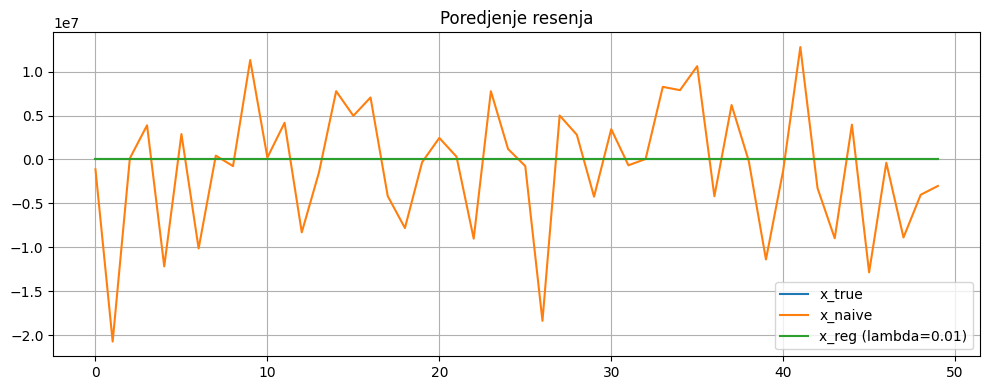

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(x_true, label='x_true')
plt.plot(x_naive, label='x_naive')
plt.plot(x_reg, label=f'x_reg (lambda={lmbda})')
plt.legend()
plt.title("Poredjenje resenja")
plt.grid(True)
plt.tight_layout()
plt.show()

**д)** Када матрица $K$ није инвертибилна (сингуларна је), уместо $K^{-1}$ користимо Мур–Пенроузов псеудоинверз $K^{+}$.
Решење
$$
x_{MP} = K^{+} y
$$
је решење које минимизује норму остатка $\|Kx - y\|_2$, а међу свим таквим решењима
бира оно са најмањом нормом $\|x\|_2$.

ВАШ ЗАДАТАК:
1. Израчунати решење преко Мур-Пенроузовог псеудоинверза: `x_mp = np.linalg.pinv(K) @ y_noisy`
2. Израчунати решење преко Тихоновљеве регуларизације: `lmbda = 0.01`,  `x_reg = np.linalg.solve(K + n*lmbda*np.eye(n), y_noisy)`
3. Упоредити грешке:  `err_mp = np.linalg.norm(x_mp - x_true)`,  `err_reg = np.linalg.norm(x_reg - x_true)`
4. Нацртати графике и објаснити зашто `x_mp` "експлодира" (има велике вредности), док је `c_reg` глатко и близу `c_true`.

(10 поена)

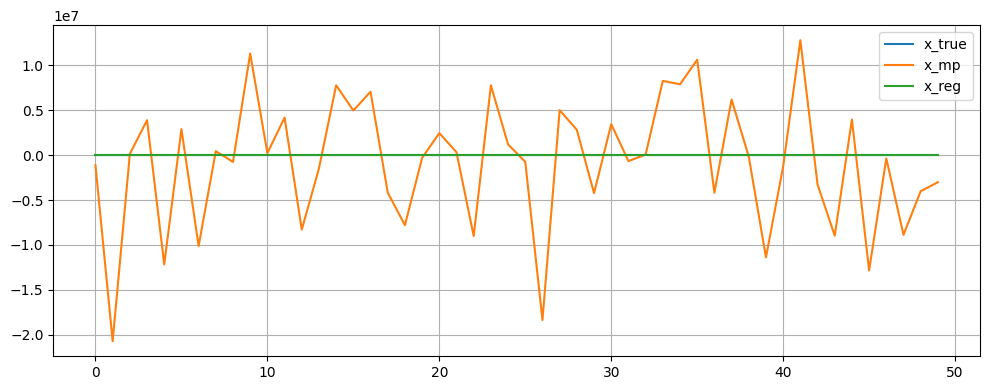

In [7]:
x_mp = np.linalg.pinv(K) @ y_noisy
lmbda = 0.01
x_reg = np.linalg.solve(K + n*lmbda*np.eye(n), y_noisy)

err_mp = np.linalg.norm(x_mp - x_true)
err_reg = np.linalg.norm(x_reg - x_true)

plt.figure(figsize=(10, 4))
plt.plot(x_true, label='x_true')
plt.plot(x_mp, label='x_mp')
plt.plot(x_reg, label='x_reg')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

***

**Задатак 3.** У претходном задатку смо анализирали апстрактну матрицу $K.$ У обради сигнала и слика, оператор замућења (blur) се често моделује као конволуција, која се у линеарној алгебри представља преко Теплицове матрице. Ово је типичан пример инверзног проблема: желимо да из замућеног и зашумљеног сигнала 
$y$ повратимо оригинални оштар сигнал $x.$

Дат је систем
$$
y = Ax + \varepsilon,
$$
где је $A$ матрица замућења, а $\varepsilon$ адитивни шум.
Користимо регуларизацију да пронађемо приближно решење оптимизационог проблема:
$$
\min_x \; \|Ax - y\|_2^2 + \lambda \|x\|_2^2.
$$
У машинском учењу, члан $ \lambda \|x\|_2^2 $ називамо $L_2$ регуларизацијом која спречава преприлагођавање (overfitting) тако што кажњава превелике вредности норме вектора $x$.

Проблем минимизације збира два квадрата $\|Ax - y\|_2^2 + \lambda \|x\|_2^2$ можемо записати као јединствен проблем најмањих квадрата коришћењем проширених  матрица.
Дефинишимо проширену матрицу $\tilde{A}$ и проширени вектор $\tilde{y}$ на следећи начин:
$ \tilde{A} = \begin{bmatrix} A \\ \lambda I \end{bmatrix}, \quad \tilde{y} = \begin{bmatrix} y \\ 0 \end{bmatrix}. $

**а)** Показати да важи следећа једнакост:
$ \|\tilde{A}x - \tilde{y}\|_2^2 = \|Ax - y\|_2^2 + \lambda \|x\|_2^2. $

(5 поена)

\begin{align*}
\|\tilde{A}x - \tilde{y}\|_2^2 &= (\tilde{A}x-\tilde{y})^T(\tilde{A}x-\tilde{y})\\
\tilde{A}x-\tilde{y} &= \begin{bmatrix} Ax - y \\ \lambda x \end{bmatrix}\\
(\tilde{A}x-\tilde{y})^T(\tilde{A}x-\tilde{y})&= \begin{bmatrix} Ax - y \\ \lambda x \end{bmatrix}^T\begin{bmatrix} Ax - y \\ \lambda x \end{bmatrix} \\
&= \begin{bmatrix} (Ax - y)^T & \lambda x^T \end{bmatrix} \begin{bmatrix} Ax - y \\ \lambda x \end{bmatrix}\\
&= (Ax - y)^T(Ax - y) + \lambda x^Tx\\
&= \|Ax - y\|_2^2 + \lambda \|x\|_2^2\\
\end{align*}

**б)** Из линеарне регресије знамо да проблем најмањих квадрата
$ \min_x \|\tilde{A}x - \tilde{y}\|_2^2 $
има решење дефинисано нормалним једначинама
$ \tilde{A}^T \tilde{A} x = \tilde{A}^T \tilde{y}. $

Израчунати производе блока матрица $\tilde{A}^T \tilde{A}$ и $\tilde{A}^T \tilde{y}$ и доказати да се добија систем:
$ (A^T A + \lambda I)x = A^T y. $

(5 поена)

\begin{align*}
\tilde{A}^T\tilde{A} &= \begin{bmatrix} A^T & \lambda I \end{bmatrix}\begin{bmatrix} A \\ \lambda I \end{bmatrix}\\
\tilde{A}^T\tilde{A} &= A^TA + \lambda^2 I\\
\\
\tilde{A}^T\tilde{y} &= \begin{bmatrix} A^T & \lambda I \end{bmatrix} \begin{bmatrix} y \\ 0 \end{bmatrix} = A^Ty\\
\\
&\Rightarrow (A^TA + \lambda^2 I)x = A^Ty
\end{align*}

**в)** Активирати код за симулацију замућења.

In [8]:
# 1. Генерисање оригиналног сигнала x (оштри скокови)
n = 100
x_true = np.zeros(n)
x_true[20:40] = 1.0
x_true[60:80] = 0.5

# 2. Формирање матрице замућења A (Gaussian blur)
c = np.exp(-np.linspace(0, 10, 10)**2 / 2) # Гаусово језгро
column = np.zeros(n)
column[:len(c)] = c
A = toeplitz(column)

# 3. Добијање замућеног сигнала y уз додатак малог шума
y_pure = A @ x_true
noise = np.random.normal(0, 0.05, n)
y = y_pure + noise

ВАШ ЗАДАТАК:  реализовати рестаурацију
1. Решити систем (A.T @ A + lmbda * I)x = A.T @ y за lmbda = 0.01
2. Израчунати решење преко псеудоинверза x_pinv = np.linalg.pinv(A) @ y
3. На истом графику приказати x_true, y, x_pinv и x_ridge (рестаурисан сигнал)

(15 поена)

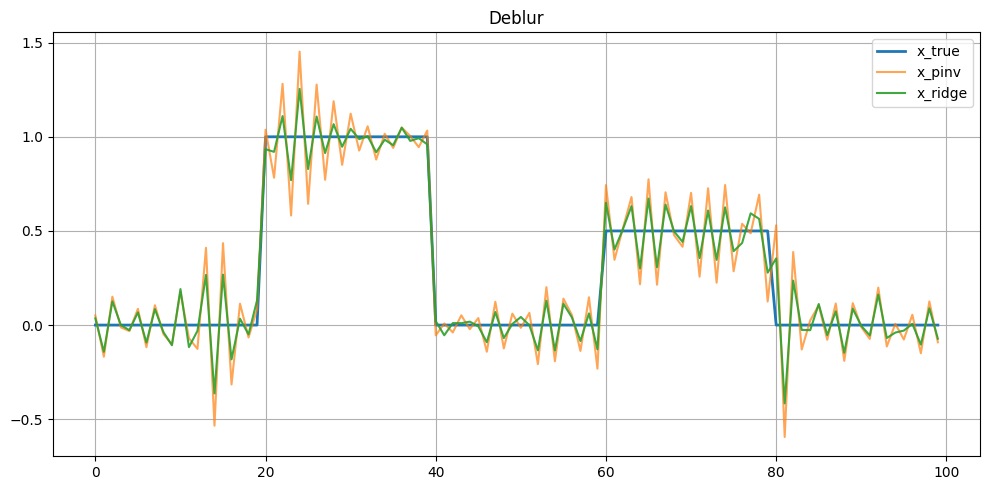

In [9]:
lmbda = 0.01
x_ridge = np.linalg.solve(A.T @ A + lmbda * np.eye(n), A.T @ y)
x_pinv = np.linalg.pinv(A)@y

plt.figure(figsize=(10, 5))
plt.plot(x_true, label='x_true', linewidth=2)
plt.plot(x_pinv, label='x_pinv', alpha=0.7)
plt.plot(x_ridge, label=f'x_ridge', alpha=0.9)
plt.legend()
plt.grid(True)
plt.title("Deblur")
plt.tight_layout()
plt.show()

**г)** На основу визуелног резултата, објасните зашто кажемо да регуларизација уводи пристрасност (bias) како би смањила варијансу (noise amplification). Како изгледа сигнал `x_ridge` у поређењу са `x_true` на местима где су скокови оштри?

(5 поена)

Regularizacija kažnjava prevelike vrednosti norme vektora $x$ pa na mestima gde su oštri prelazi u originalnom signalu dolazi do uglađivanja signala. Bez regularizacije bi rešavanje sistema dovelo do što boljeg fittovanja, tj overfittinga. Regularizacija pokušava da prelazi između vrednosti u $x_ridge$ budu manji, tj da vrednost $x_{ridge}$ bude što manja kako bi se smanjila kazna.

***

**Задатак 4.** СВД декомпозиција матрице $A \in M_{m \times n}$ ранга $r$ гласи
$ A = U \Sigma V^T. $

Матрицу $A$ можемо записати и као суму $r$ матрица ранга 1 (спољашњих производа):
$ A = \sum_{i=1}^{r} \sigma_i u_i v_i^T. $

Овај приказ нам омогућава да направимо апроксимацију ниског ранга $A_k$ тако што задржимо само првих $k$ највећих сингуларних вредности:
$ A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T, \quad k < r. $

**а)** На основу Екарт–Јанг–Мирски теореме, апроксимација $A_k$ је најбоља апроксимација ранга $k$ у смислу Фробенијусове норме.  

Питање: Колико износи квадрат грешке апроксимације $\|A - A_k\|_F^2$ изражен преко одбачених сингуларних вредности?

(5 поена)

\begin{align*}
A &= \sum_{i=1}^r \sigma_i u_i v_i^T\\
A_k &= \sum_{i=1}^k \sigma_i u_i v_i^T\\
A - A_k &= \sum_{i=k+1}^r \sigma_i u_i v_i^T
\\
U^TU &= I, V^TV = I\\
\|A\|_F^2 &= Tr(A^TA)\\
&= Tr((U\Sigma V^T)^TU\Sigma V^T)\\
&= Tr(V\Sigma^TU^T U \Sigma V^T)\\
&= Tr(V\Sigma^T\Sigma V^T)\\
&= Tr(V^TV\Sigma^T\Sigma)\\
&= Tr(\Sigma^T\Sigma)\\
&= \sum_{i=1}^{r} \sigma_i^2\\
&\Rightarrow \|A - A_k\| =\sum_{i=k+1}^{r} \sigma_i^2
\end{align*}


б) У AI апликацијама често меримо проценат „сачуване информације“ (енергије) преко израза
$$ E(k) = \dfrac{\|A_k\|_F^2}{\|A\|_F^2}
       = \dfrac{\sum_{i=1}^{k} \sigma_i^2}{\sum_{i=1}^{r} \sigma_i^2}. $$
Ако желимо да компресујемо матрицу $A$ тако да сачувамо **95% информација**, потребно је изабрати најмањи број компоненти $k$ који задовољава услов?

In [10]:
import scipy.datasets as scd

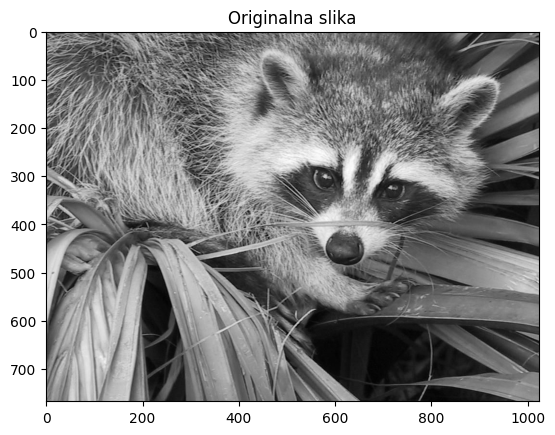

In [11]:
rakun=scd.face()
sk_vredn=rakun/255
A = sk_vredn @ [0.2126, 0.7152, 0.0722]
A.shape
plt.imshow(A, cmap="gray");
plt.title("Originalna slika");

ВАШ ЗАДАТАК:
1. Нацртати график сингуларних вредности (S) на логаритамској скали. Шта нам овај график говори о могућности компресије ове слике?
2. Нацртати график кумулативне енергије E(k) у функцији од k. Пронаћи најмање k за које је E(k) > 0.95 (95% енергије).
3. Реконструисати слику A_k за k = 5, 20, 50 и за k који даје 95% енергије.
4. Израчунати однос компресије за свако k.
   - Оригинал број података: m * n
   - Компресован број података: k * (m + n + 1)
   - Ratio = (m * n) / (k * (m + n + 1))
5. Приказати оригинале и реконструисане слике једу поред друге.

(5 поена)

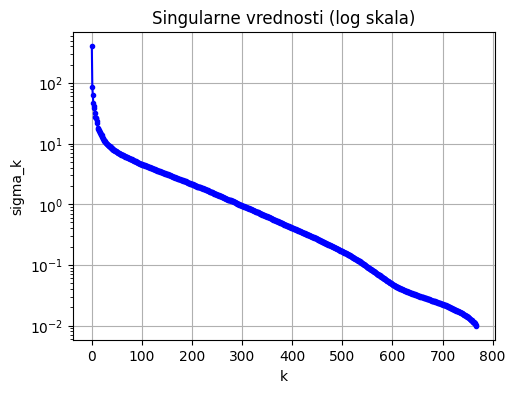

In [19]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.semilogy(S, 'b-o', markersize=3)
plt.xlabel("k")
plt.ylabel("sigma_k")
plt.title("Singularne vrednosti (log skala)")
plt.grid(True)

S obzirom da matricu $A$ čiju dekompoziciju vršimo možemo smatrati kao sumu u kojoj je $\sigma_i$ faktor, onda će dati faktor određivati uticaj svake od komponenti u dekompoziciji. Na grafiku vidimo da imamo oko 800 komponenti, pri čemu prve 300 imaju značajan uticaj. Odbacivanjem elemenata sa malim $\sigma$ vrednostima možemo dosta smanjiti veličinu slike.

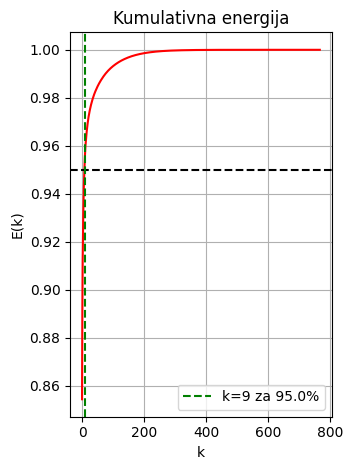

k za 95.0% energije: 9


In [25]:
energija = np.cumsum(S**2) / np.sum(S**2)
limit = 0.95
plt.subplot(1, 2, 2)
plt.plot(energija, 'r-')
k_limit = np.searchsorted(energija, limit) + 1
plt.axhline(limit, linestyle='--', color='k')
plt.axvline(k_limit, linestyle='--', color='g', label=f"k={k_limit} za {limit * 100}%")
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title("Kumulativna energija")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"k za {limit*100}% energije: {k_limit}")

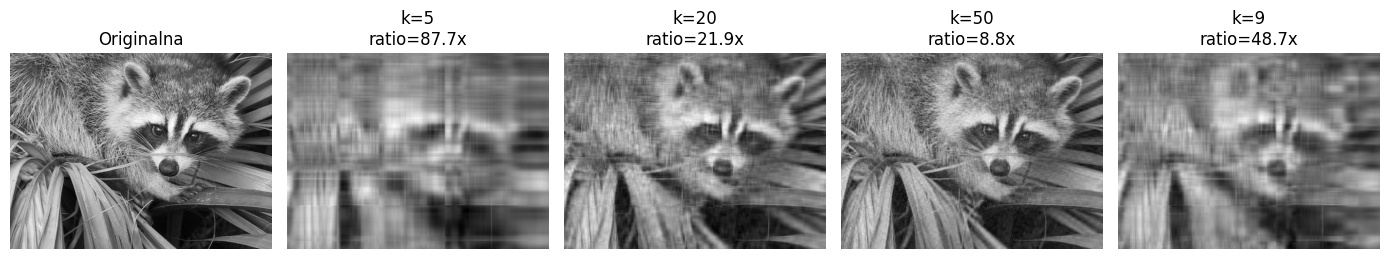

In [26]:
m, n = A.shape
k_vals = [5, 20, 50, k_limit]
fig, axes = plt.subplots(1, len(k_vals)+1, figsize=(14, 4))
axes[0].imshow(A, cmap='gray'); axes[0].set_title("Originalna"); axes[0].axis('off')

for i, k in enumerate(k_vals):
    A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    ratio = (m * n) / (k * (m + n + 1))
    axes[i+1].imshow(A_k, cmap='gray')
    axes[i+1].set_title(f"k={k}\nratio={ratio:.1f}x")
    axes[i+1].axis('off')
plt.tight_layout()
plt.show()

**в)** Често мали пиксели (шум) утичу на најмање сингуларне вредности.
Покушајте да додате случајан шум слици:

In [36]:
A_noisy = A + 0.1 * np.random.randn(*A.shape)

Примените СВД и реконструишите слику са $k = 30$.

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

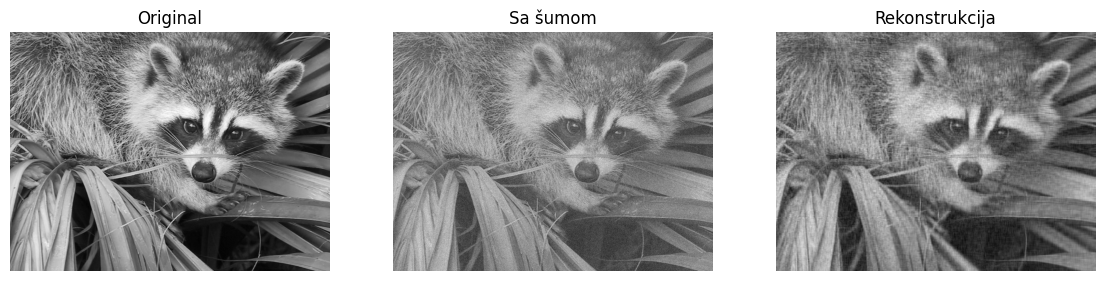

In [38]:
U, S, Vt = np.linalg.svd(A_noisy, full_matrices=False)
k = 50
A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(A, cmap='gray')
axes[0].set_title(f"Original")
axes[0].axis('off')

axes[1].imshow(A_noisy, cmap='gray')
axes[1].set_title(f"Sa šumom")
axes[1].axis('off')

axes[2].imshow(A_k, cmap='gray')
axes[2].set_title(f"Rekonstrukcija")
axes[2].axis('off')

Објасните зашто СВД апроксимација ниског ранга може да послужи као метода за чишћење шума (denoising). Повежите ово са претходним задатком о регуларизацији и стабилности инверзних проблема.

(10 поена)

$\sigma$ vrednosti u SVD dekompoziciju označavaju jačinu komponenti. Velike vrednosti nose strukturu, tj najbitnije signale u slici, dok će šum završiti u malim komponentama. Uzimanjem samo komponenti sa najvećim $\sigma$ vrednosti efektivno vršimo denoising.

Да ли би СВД компресија подједнако добро радила на слици која представља чисто бели шум (random noise)? Зашто? (Помоћ: Размислите о брзини опадања сингуларних вредности).

(10 поена)

S obzirom da na slici sa čisto belim šumom nema struktura, sve singularne vrednosti će biti slične. tj neće biti brzog opadanja kao kod prošlog primera. Kod prethodne slike mali broj komponenti nosi većinu značaja/energije, dok je kod belog šuma ravnomerno raspoređena. Da bi u tom slučaju vršili kompresiju moramo uzeti veliko $k$, u suprotnom gubimo strukturu. S obzirom da beli šum nema strukture, SVD će ga teško kompresovati.

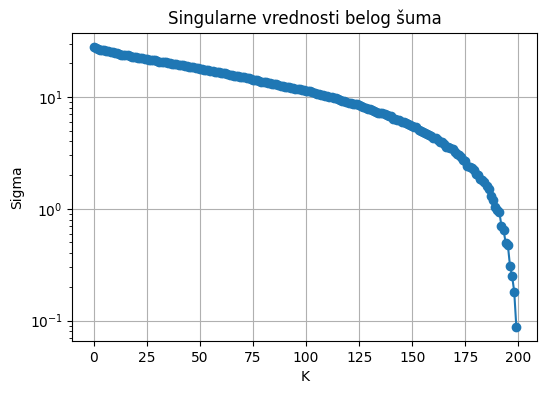

In [40]:
np.random.seed(0)
A_noise = np.random.randn(200, 200)

U, S, Vt = np.linalg.svd(A_noise, full_matrices=False)
plt.figure(figsize=(6,4))
plt.semilogy(S, 'o-')
plt.title("Singularne vrednosti belog šuma")
plt.xlabel("K")
plt.ylabel("Sigma")
plt.grid()
plt.show()
# vidimo dosta sporiji pad, i tek brzi pad sigma vrednosti oko 175-e komponente

***